## 1. Setup

In [14]:
# 0. Import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("../src")
from prepare_data import DATASETS

def rule_violations(series, lo, hi):
    bad = series < float("-inf")
    if lo is not None:
        bad = bad | (series < lo)
    if hi is not None:
        bad = bad | (series > hi)
    return bad

In [15]:
# 1. Load
DATASET = "credit_card"
TARGET = DATASETS[DATASET]["target"]
CONT = DATASETS[DATASET]["continuous"]
CODES = DATASETS[DATASET]["codes"]
BOUNDS = DATASETS[DATASET]["bounds"]
MESSY_DIR = f"../data/messy/{DATASET}"
CONDITIONS = ["clean", "missing_mild", "missing_severe",
              "outlier_mild", "outlier_severe", "noise_mild", "noise_severe"]

dfs = {}
for c in CONDITIONS:
    path = f"{MESSY_DIR}/{c}/train.csv"
    dfs[c] = pd.read_csv(path)
test_df = pd.read_csv(f"../data/processed/{DATASET}/test.csv")

for c, d in dfs.items():
    print(f"{c:<16} shape={d.shape}  missing={d.isnull().mean().mean():.2%}  pos_rate={d[TARGET].mean():.3f}")
print(f"{'test':<16} shape={test_df.shape}")

clean            shape=(24000, 24)  missing=0.00%  pos_rate=0.221
missing_mild     shape=(24000, 24)  missing=9.58%  pos_rate=0.221
missing_severe   shape=(24000, 24)  missing=19.17%  pos_rate=0.221
outlier_mild     shape=(24000, 24)  missing=0.00%  pos_rate=0.221
outlier_severe   shape=(24000, 24)  missing=0.00%  pos_rate=0.221
noise_mild       shape=(24000, 24)  missing=0.00%  pos_rate=0.249
noise_severe     shape=(24000, 24)  missing=0.00%  pos_rate=0.331
test             shape=(6000, 24)


## 2. EDA

Following the protocol:
1. Basic data loading check (shape, info, columns, describe)
2. Basic descriptive stats (mean, median, std, skew)
3. Missing value profile (% and pattern)
4. Outlier profile (distribution shape, IQR count)
5. Class balance profile (check class balance)
6. Correlation matrix

In [16]:
# 1. Basic data loading (all conditions + test)
all_dfs = dfs.copy()
all_dfs["test"] = test_df

for name, d in all_dfs.items():
    print(f"\n{'='*70}\n  {name.upper()}\n{'='*70}")
    print(f"Data Shape: {d.shape}")
    print("\nData Info:")
    d.info()
    print("\nData Columns:")
    print(d.columns.tolist())
    print("\nData Description:")
    display(d.describe())


  CLEAN
Data Shape: (24000, 24)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   24000 non-null  float64
 1   SEX                         24000 non-null  int64  
 2   EDUCATION                   24000 non-null  int64  
 3   MARRIAGE                    24000 non-null  int64  
 4   AGE                         24000 non-null  int64  
 5   PAY_0                       24000 non-null  int64  
 6   PAY_2                       24000 non-null  int64  
 7   PAY_3                       24000 non-null  int64  
 8   PAY_4                       24000 non-null  int64  
 9   PAY_5                       24000 non-null  int64  
 10  PAY_6                       24000 non-null  int64  
 11  BILL_AMT1                   24000 non-null  float64
 12  BILL_AMT2                   24000 non-null 

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,...,24000.000000,24000.000000,24000.000000,24000.000000,2.400000e+04,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000
mean,167364.666667,1.604750,1.853792,1.552875,35.432625,-0.014125,-0.134083,-0.166917,-0.221333,-0.270333,...,43156.661458,40164.412625,38675.979875,5623.556292,5.879975e+03,5215.777583,4790.331833,4769.941750,5229.905500,0.221208
std,129511.313151,0.488915,0.792375,0.521903,9.195256,1.123155,1.198818,1.194166,1.161924,1.125192,...,64046.730878,60627.850612,59308.737828,16148.316646,2.025298e+04,17513.554475,15060.693585,15048.470405,17850.346975,0.415069
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-81334.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2332.000000,1746.000000,1225.000000,1000.000000,8.400000e+02,390.000000,291.000000,246.000000,100.000000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19004.500000,18102.500000,16993.000000,2100.500000,2.014000e+03,1805.500000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54386.500000,50142.250000,48977.250000,5018.250000,5.000000e+03,4580.500000,4015.250000,4040.000000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,75.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.215471e+06,896040.000000,621000.000000,426529.000000,528666.000000,1.000000



  MISSING_MILD
Data Shape: (24000, 24)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   21600 non-null  float64
 1   SEX                         21600 non-null  float64
 2   EDUCATION                   21600 non-null  float64
 3   MARRIAGE                    21600 non-null  float64
 4   AGE                         21600 non-null  float64
 5   PAY_0                       21600 non-null  float64
 6   PAY_2                       21600 non-null  float64
 7   PAY_3                       21600 non-null  float64
 8   PAY_4                       21600 non-null  float64
 9   PAY_5                       21600 non-null  float64
 10  PAY_6                       21600 non-null  float64
 11  BILL_AMT1                   21600 non-null  float64
 12  BILL_AMT2                   21600 no

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,...,21600.000000,21600.000000,21600.000000,21600.000000,2.160000e+04,21600.000000,21600.000000,21600.000000,21600.00000,24000.000000
mean,167158.425926,1.605324,1.850833,1.553380,35.416019,-0.009815,-0.133102,-0.164861,-0.223380,-0.270278,...,43198.825556,40126.556296,38710.549074,5586.366667,5.825967e+03,5217.917222,4794.347083,4756.093843,5209.91963,0.221208
std,129140.176325,0.488792,0.793201,0.522136,9.194917,1.124170,1.198142,1.194342,1.162742,1.124092,...,64091.559611,60274.418045,59286.692833,15999.470696,1.880367e+04,17623.062783,15023.628626,14879.937347,17685.67096,0.415069
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-46627.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.00000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2350.000000,1762.750000,1205.750000,1000.000000,8.360000e+02,390.000000,300.000000,264.000000,121.75000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19034.500000,18124.000000,17000.000000,2100.000000,2.011000e+03,1800.000000,1500.000000,1516.000000,1500.00000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54401.000000,50259.250000,48970.250000,5009.250000,5.000000e+03,4556.250000,4033.250000,4100.000000,4000.00000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,75.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,699944.000000,873552.000000,1.024516e+06,896040.000000,621000.000000,426529.000000,528666.00000,1.000000



  MISSING_SEVERE
Data Shape: (24000, 24)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   19200 non-null  float64
 1   SEX                         19200 non-null  float64
 2   EDUCATION                   19200 non-null  float64
 3   MARRIAGE                    19200 non-null  float64
 4   AGE                         19200 non-null  float64
 5   PAY_0                       19200 non-null  float64
 6   PAY_2                       19200 non-null  float64
 7   PAY_3                       19200 non-null  float64
 8   PAY_4                       19200 non-null  float64
 9   PAY_5                       19200 non-null  float64
 10  PAY_6                       19200 non-null  float64
 11  BILL_AMT1                   19200 non-null  float64
 12  BILL_AMT2                   19200 

...

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,...,24000.000000,24000.000000,24000.000000,24000.000000,2.400000e+04,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000
mean,167364.666667,1.604750,1.853792,1.552875,35.432625,-0.014125,-0.134083,-0.166917,-0.221333,-0.270333,...,43156.661458,40164.412625,38675.979875,5623.556292,5.879975e+03,5215.777583,4790.331833,4769.941750,5229.905500,0.249125
std,129511.313151,0.488915,0.792375,0.521903,9.195256,1.123155,1.198818,1.194166,1.161924,1.125192,...,64046.730878,60627.850612,59308.737828,16148.316646,2.025298e+04,17513.554475,15060.693585,15048.470405,17850.346975,0.432515
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-81334.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2332.000000,1746.000000,1225.000000,1000.000000,8.400000e+02,390.000000,291.000000,246.000000,100.000000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19004.500000,18102.500000,16993.000000,2100.500000,2.014000e+03,1805.500000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54386.500000,50142.250000,48977.250000,5018.250000,5.000000e+03,4580.500000,4015.250000,4040.000000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,75.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.215471e+06,896040.000000,621000.000000,426529.000000,528666.000000,1.000000



  NOISE_SEVERE
Data Shape: (24000, 24)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   24000 non-null  float64
 1   SEX                         24000 non-null  int64  
 2   EDUCATION                   24000 non-null  int64  
 3   MARRIAGE                    24000 non-null  int64  
 4   AGE                         24000 non-null  int64  
 5   PAY_0                       24000 non-null  int64  
 6   PAY_2                       24000 non-null  int64  
 7   PAY_3                       24000 non-null  int64  
 8   PAY_4                       24000 non-null  int64  
 9   PAY_5                       24000 non-null  int64  
 10  PAY_6                       24000 non-null  int64  
 11  BILL_AMT1                   24000 non-null  float64
 12  BILL_AMT2                   24000 no

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,...,24000.000000,24000.000000,24000.000000,24000.000000,2.400000e+04,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000
mean,167364.666667,1.604750,1.853792,1.552875,35.432625,-0.014125,-0.134083,-0.166917,-0.221333,-0.270333,...,43156.661458,40164.412625,38675.979875,5623.556292,5.879975e+03,5215.777583,4790.331833,4769.941750,5229.905500,0.330875
std,129511.313151,0.488915,0.792375,0.521903,9.195256,1.123155,1.198818,1.194166,1.161924,1.125192,...,64046.730878,60627.850612,59308.737828,16148.316646,2.025298e+04,17513.554475,15060.693585,15048.470405,17850.346975,0.470538
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-81334.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2332.000000,1746.000000,1225.000000,1000.000000,8.400000e+02,390.000000,291.000000,246.000000,100.000000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19004.500000,18102.500000,16993.000000,2100.500000,2.014000e+03,1805.500000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54386.500000,50142.250000,48977.250000,5018.250000,5.000000e+03,4580.500000,4015.250000,4040.000000,4000.000000,1.000000
max,1000000.000000,2.000000,6.000000,3.000000,75.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.215471e+06,896040.000000,621000.000000,426529.000000,528666.000000,1.000000



  TEST
Data Shape: (6000, 24)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   6000 non-null   float64
 1   SEX                         6000 non-null   int64  
 2   EDUCATION                   6000 non-null   int64  
 3   MARRIAGE                    6000 non-null   int64  
 4   AGE                         6000 non-null   int64  
 5   PAY_0                       6000 non-null   int64  
 6   PAY_2                       6000 non-null   int64  
 7   PAY_3                       6000 non-null   int64  
 8   PAY_4                       6000 non-null   int64  
 9   PAY_5                       6000 non-null   int64  
 10  PAY_6                       6000 non-null   int64  
 11  BILL_AMT1                   6000 non-null   float64
 12  BILL_AMT2                   6000 non-null   flo

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,...,6000.000000,6000.000000,6000.000000,6000.000000,6.000000e+03,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,167962.946667,1.599667,1.850500,1.547833,35.697000,-0.027000,-0.132500,-0.163333,-0.218000,-0.249667,...,43688.099000,40899.354333,39654.882500,5823.677333,6.085918e+03,5265.297167,4969.057000,4917.171167,5157.890833,0.221167
std,130698.538357,0.490007,0.782252,0.522262,9.305713,1.126417,1.190734,1.207711,1.197657,1.164571,...,65468.536253,61471.293451,60524.310508,18128.961193,3.184007e+04,17977.164797,17884.895787,16165.776457,17484.253835,0.415067
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-53007.000000,-150953.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2302.500000,1885.000000,1368.500000,934.750000,7.920000e+02,391.000000,300.000000,279.750000,189.000000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19201.500000,18144.500000,17339.500000,2100.000000,2.000000e+03,1800.000000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54859.000000,50480.500000,49883.750000,5000.000000,5.000000e+03,4366.250000,4003.250000,4021.250000,4122.250000,0.000000
max,800000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,7.000000,8.000000,8.000000,7.000000,...,706864.000000,514114.000000,499100.000000,493358.000000,1.684259e+06,417588.000000,528897.000000,379267.000000,443001.000000,1.000000


In [17]:
# 2. Basic descriptive stats (mean, median, std, skew)

# number columns only
num_cols = CONT

d = all_dfs["clean"][num_cols]
stats = pd.DataFrame({
    "mean": d.mean(), "median": d.median(), "std": d.std(), "skew": d.skew()
}).round(3)

print(stats.to_string())

                 mean    median         std    skew
LIMIT_BAL  167364.667  140000.0  129511.313   1.000
AGE            35.433      34.0       9.195   0.738
BILL_AMT1   51100.502   22330.0   73510.032   2.691
BILL_AMT2   49012.268   21107.0   70840.102   2.728
BILL_AMT3   46861.880   20031.0   68403.934   2.729
BILL_AMT4   43156.661   19004.5   64046.731   2.823
BILL_AMT5   40164.413   18102.5   60627.851   2.920
BILL_AMT6   38675.980   16993.0   59308.738   2.882
PAY_AMT1     5623.556    2100.5   16148.317  15.312
PAY_AMT2     5879.975    2014.0   20252.983  21.124
PAY_AMT3     5215.778    1805.5   17513.554  18.638
PAY_AMT4     4790.332    1500.0   15060.694  12.376
PAY_AMT5     4769.942    1500.0   15048.470  11.131
PAY_AMT6     5229.906    1500.0   17850.347  10.549


In [18]:
# 3. Missing value profile (% per column, all conditions)
missing_pct = pd.DataFrame(
    {name: d.isnull().mean() * 100 for name, d in all_dfs.items()}
).round(2)

print("Missing Value in % (per column, per condition):")
print(missing_pct.to_string())

print("\nOverall missing % per condition:")
print(missing_pct.mean().round(2).to_string())

print("\nInjected missing % (CONT + CODES only):")
for name, d in all_dfs.items():
    rate = d[CONT + CODES].isnull().mean().mean() * 100
    print(f"  {name:<16} {rate:.2f}")

Missing Value in % (per column, per condition):
                            clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe  test
LIMIT_BAL                     0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
SEX                           0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
EDUCATION                     0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
MARRIAGE                      0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
AGE                           0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
PAY_0                         0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
PAY_2                         0.0          10.0            20.0       

  clean            0.00
  missing_mild     10.00
  missing_severe   20.00
  outlier_mild     0.00
  outlier_severe   0.00
  noise_mild       0.00
  noise_severe     0.00
  test             0.00


In [19]:
# 3b. Missing pattern
for name in ["missing_mild", "missing_severe"]:
    d = all_dfs[name]
    print(f"\n{name.upper()} - missing % by class (0 / 1):")
    for col in CONT + CODES:
        rate0 = d.loc[d[TARGET] == 0, col].isna().mean() * 100
        rate1 = d.loc[d[TARGET] == 1, col].isna().mean() * 100
        print(f"  {col:<25} {rate0:6.2f}  {rate1:6.2f}")


MISSING_MILD - missing % by class (0 / 1):
  LIMIT_BAL                   9.89   10.40
  AGE                        10.02    9.93
  BILL_AMT1                  10.06    9.79
  BILL_AMT2                   9.88   10.44
  BILL_AMT3                  10.01    9.96
  BILL_AMT4                   9.94   10.21
  BILL_AMT5                   9.95   10.17
  BILL_AMT6                  10.06    9.78
  PAY_AMT1                    9.95   10.17
  PAY_AMT2                    9.97   10.11
  PAY_AMT3                   10.07    9.74
  PAY_AMT4                   10.09    9.68
  PAY_AMT5                   10.12    9.59
  PAY_AMT6                    9.99   10.04
  SEX                        10.07    9.76
  EDUCATION                  10.04    9.87
  MARRIAGE                   10.15    9.46
  PAY_0                      10.22    9.23
  PAY_2                      10.06    9.79
  PAY_3                      10.03    9.89
  PAY_4                      10.05    9.83
  PAY_5                      10.01    9.96
  PAY_6   

In [20]:
# 4. Outlier profile (distribution shape, IQR count)
def iqr_outlier_pct(d, cols):
    out = {}
    for c in cols:
        x = d[c].dropna()
        q1, q3 = x.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out[c] = ((x < lo) | (x > hi)).mean() * 100
    return pd.Series(out)

outlier_pct = pd.DataFrame(
    {name: iqr_outlier_pct(d, num_cols) for name, d in all_dfs.items()}
).round(2)

print("IQR outlier % (per column, per condition):")
print(outlier_pct.to_string())

skew = pd.DataFrame(
    {name: d[num_cols].skew() for name, d in all_dfs.items()}
).round(2)

print("\nSkewness (per column, per condition):")
print(skew.to_string())

IQR outlier % (per column, per condition):
           clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe   test
LIMIT_BAL   0.57          0.55            0.54          5.32           11.78        0.57          0.57   0.52
AGE         0.89          0.89            0.89          4.98            7.13        0.89          0.89   0.50
BILL_AMT1   7.91          7.93            8.10         11.68           19.26        7.91          7.91   8.27
BILL_AMT2   7.91          7.95            8.08         11.72           19.23        7.91          7.91   8.30
BILL_AMT3   8.25          8.24            8.04         11.92           19.41        8.25          8.25   8.22
BILL_AMT4   8.77          8.79            8.97         12.13           19.42        8.77          8.77   8.65
BILL_AMT5   9.11          9.07            9.09         12.72           19.57        9.11          9.11   8.93
BILL_AMT6   9.00          8.96            8.97         12.92           19.95 

In [21]:
# Ground-truth injection rate + range check
check_cols = CONT + CODES
clean = all_dfs["clean"]

for cond in ["outlier_mild", "outlier_severe"]:
    d = all_dfs[cond]
    changed = (d[check_cols] != clean[check_cols]).mean() * 100
    summary = pd.DataFrame({
        "changed_%": changed.round(2),
        "clean_min": clean[check_cols].min(),
        "clean_max": clean[check_cols].max(),
        f"{cond}_min": d[check_cols].min(),
        f"{cond}_max": d[check_cols].max(),
        "clean_std": clean[check_cols].std().round(2),
        f"{cond}_std": d[check_cols].std().round(2),
    })
    print(f"\n{cond.upper()}")
    print(summary.to_string())


OUTLIER_MILD
           changed_%  clean_min  clean_max  outlier_mild_min  outlier_mild_max  clean_std  outlier_mild_std
LIMIT_BAL        5.0    10000.0  1000000.0    -350569.557094         1000000.0  129511.31         162353.53
AGE              5.0       21.0       75.0         -1.000000              75.0       9.20             11.52
BILL_AMT1        5.0  -165580.0   964511.0    -242548.238479          964511.0   73510.03          92074.63
BILL_AMT2        5.0   -69777.0   983931.0    -234342.893309          983931.0   70840.10          88733.38
BILL_AMT3        5.0   -61506.0   855086.0    -226732.057470          855086.0   68403.93          85541.97
BILL_AMT4        5.0   -81334.0   891586.0    -212976.076885          891586.0   64046.73          80376.76
BILL_AMT5        5.0   -81334.0   927171.0    -202253.454270          927171.0   60627.85          75672.34
BILL_AMT6        5.0  -339603.0   961664.0    -339603.000000          961664.0   59308.74          74416.72
PAY_AMT1      

In [22]:
# 5. Class balance profile (check class balance)
balance = pd.DataFrame(
    {name: d[TARGET].value_counts(normalize=True).sort_index() * 100 for name, d in all_dfs.items()}
).round(2)

print("Class balance % (y=0 / y=1):")
print(balance.to_string())

Class balance % (y=0 / y=1):
                            clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe   test
default.payment.next.month                                                                                                    
0                           77.88         77.88           77.88         77.88           77.88       75.09         66.91  77.88
1                           22.12         22.12           22.12         22.12           22.12       24.91         33.09  22.12


In [23]:
# 5b. Direct label noise check (ground truth vs clean)
clean_y = all_dfs["clean"][TARGET]

for cond in ["noise_mild", "noise_severe"]:
    noisy_y = all_dfs[cond][TARGET]
    flipped = noisy_y != clean_y
    print(f"\n{cond.upper()}")
    print(f"  Overall flip rate : {flipped.mean():.2%}")
    print(f"  Flipped 0 → 1     : {((clean_y == 0) & flipped).sum():,} "
          f"({flipped[clean_y == 0].mean():.2%} of class 0)")
    print(f"  Flipped 1 → 0     : {((clean_y == 1) & flipped).sum():,} "
          f"({flipped[clean_y == 1].mean():.2%} of class 1)")


NOISE_MILD
  Overall flip rate : 5.00%
  Flipped 0 → 1     : 935 (5.00% of class 0)
  Flipped 1 → 0     : 265 (4.99% of class 1)

NOISE_SEVERE
  Overall flip rate : 20.00%
  Flipped 0 → 1     : 3,716 (19.88% of class 0)
  Flipped 1 → 0     : 1,084 (20.42% of class 1)


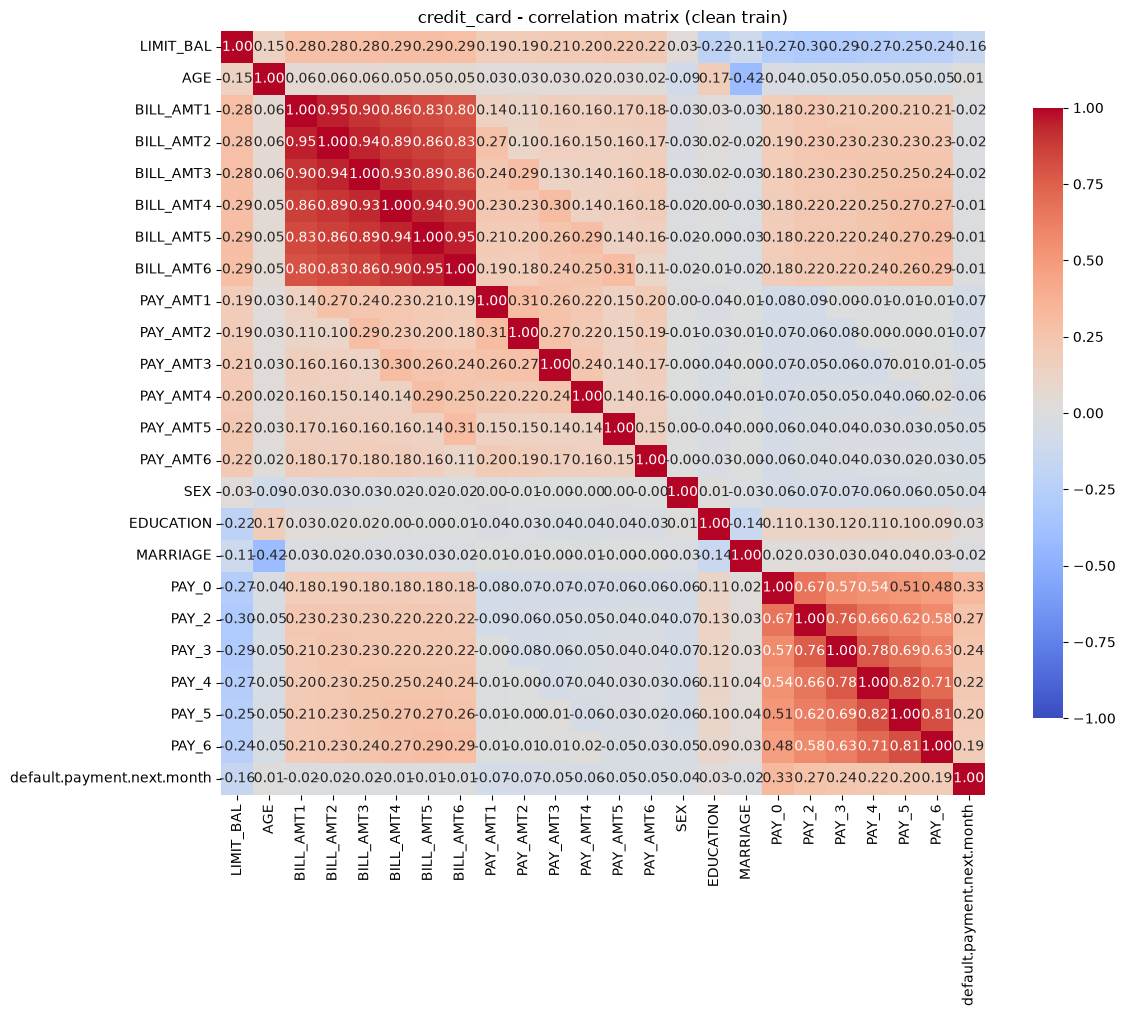

Correlation with y (per condition):
           clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe   test
LIMIT_BAL -0.161        -0.163          -0.164        -0.134          -0.095      -0.141        -0.088 -0.124
AGE        0.013         0.015           0.013         0.004           0.003       0.012         0.002  0.018
BILL_AMT1 -0.023        -0.027          -0.028        -0.024          -0.015      -0.020        -0.018 -0.007
BILL_AMT2 -0.018        -0.017          -0.020        -0.014          -0.004      -0.016        -0.015  0.001
BILL_AMT3 -0.018        -0.017          -0.016        -0.023          -0.016      -0.019        -0.016  0.002
BILL_AMT4 -0.014        -0.014          -0.011        -0.012          -0.002      -0.016        -0.016  0.004
BILL_AMT5 -0.010        -0.009          -0.007        -0.009          -0.006      -0.012        -0.015  0.005
BILL_AMT6 -0.008        -0.008          -0.010        -0.009          -0.007      -0

In [24]:
# 6. Correlation matrix
corr_cols = num_cols + CODES + [TARGET]

# 6a. Full heatmap - clean baseline
corr_clean = all_dfs["clean"][corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_clean, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8})
plt.title(f"{DATASET} - correlation matrix (clean train)")
plt.tight_layout()
plt.show()

# 6b. Correlation with target, per condition
target_corr = pd.DataFrame(
    {name: d[corr_cols].corr()[TARGET].drop(TARGET) for name, d in all_dfs.items()}
).round(3)

print("Correlation with y (per condition):")
print(target_corr.to_string())

# 6c. How much each condition distorts the whole matrix vs clean
distortion = pd.Series(
    {name: (d[corr_cols].corr() - corr_clean).abs().values.mean() for name, d in all_dfs.items()}
).round(4)

print("\nMean absolute change in correlation vs clean:")
print(distortion.to_string())

In [25]:
# 7. Catchable outliers (rule violations among injected values)
for cond in ["outlier_mild", "outlier_severe"]:
    d = all_dfs[cond]
    clean = all_dfs["clean"]
    print(f"\n{cond.upper()}")
    print(f"  {'column':<25} {'changed':>8} {'impossible':>11} {'catchable %':>12}")
    for col in CONT:
        lo, hi = BOUNDS.get(col, (None, None))
        changed = d[col] != clean[col]
        impossible = changed & rule_violations(d[col], lo, hi)
        n_changed = changed.sum()
        n_impossible = impossible.sum()
        share = n_impossible / n_changed * 100 if n_changed > 0 else 0
        print(f"  {col:<25} {n_changed:>8} {n_impossible:>11} {share:>11.1f}%")


OUTLIER_MILD
  column                     changed  impossible  catchable %
  LIMIT_BAL                     1200         584        48.7%
  AGE                           1200         581        48.4%
  BILL_AMT1                     1200           0         0.0%
  BILL_AMT2                     1200           0         0.0%
  BILL_AMT3                     1200           0         0.0%
  BILL_AMT4                     1200           0         0.0%
  BILL_AMT5                     1200           0         0.0%
  BILL_AMT6                     1200           0         0.0%
  PAY_AMT1                      1200         602        50.2%
  PAY_AMT2                      1200         617        51.4%
  PAY_AMT3                      1200         596        49.7%
  PAY_AMT4                      1200         593        49.4%
  PAY_AMT5                      1200         600        50.0%
  PAY_AMT6                      1200         585        48.8%

OUTLIER_SEVERE
  column                     changed  im

In [26]:
# 8. Validity rules on clean data (must all be 0)
clean = all_dfs["clean"]
print("Rule violations on CLEAN training data (should all be 0):")
for col in BOUNDS:
    lo, hi = BOUNDS[col]
    n_bad = rule_violations(clean[col], lo, hi).sum()
    print(f"  {col:<25} {n_bad}")

Rule violations on CLEAN training data (should all be 0):
  LIMIT_BAL                 0
  AGE                       0
  BILL_AMT1                 0
  BILL_AMT2                 0
  BILL_AMT3                 0
  BILL_AMT4                 0
  BILL_AMT5                 0
  BILL_AMT6                 0
  PAY_AMT1                  0
  PAY_AMT2                  0
  PAY_AMT3                  0
  PAY_AMT4                  0
  PAY_AMT5                  0
  PAY_AMT6                  0
  SEX                       0
  EDUCATION                 0
  MARRIAGE                  0
  PAY_0                     0
  PAY_2                     0
  PAY_3                     0
  PAY_4                     0
  PAY_5                     0
  PAY_6                     0
